## OLMo-1B

In [5]:
import torch
import json
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

# =========================
# Helpers
# =========================

def get_transformer_layers(model):
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    if hasattr(model, "model") and hasattr(model.model, "transformer") and hasattr(model.model.transformer, "blocks"):
        return model.model.transformer.blocks
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    raise ValueError("Unknown model structure")

def get_down_proj(layer):
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "down_proj"):
        return layer.mlp.down_proj
    if hasattr(layer, "feed_forward") and hasattr(layer.feed_forward, "w2"):
        return layer.feed_forward.w2
    raise ValueError("down_proj not found")

# =========================
# Collect activations
# =========================

@torch.no_grad()
def collect_activation_stats(model, tokenizer, texts):
    model.eval()
    device = next(model.parameters()).device

    layers = get_transformer_layers(model)

    # store per layer
    layer_stats = [
        {"in_max": 0.0, "out_max": 0.0}
        for _ in range(len(layers))
    ]

    hooks = []

    for i, layer in enumerate(layers):
        down_proj = get_down_proj(layer)

        def make_hook(layer_idx):
            def hook(module, inputs, outputs):
                x = inputs[0].detach()
                y = outputs.detach()

                in_val = x.abs().max().item()
                out_val = y.abs().max().item()

                layer_stats[layer_idx]["in_max"] = max(layer_stats[layer_idx]["in_max"], in_val)
                layer_stats[layer_idx]["out_max"] = max(layer_stats[layer_idx]["out_max"], out_val)
            return hook

        hooks.append(down_proj.register_forward_hook(make_hook(i)))

    # run all texts
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt").to(device)
        _ = model(**inputs)

    for h in hooks:
        h.remove()

    return layer_stats

# =========================
# Plotting
# =========================

def plot_activation(stats_dict, title, key="out_max"):
    plt.figure(figsize=(9,5))

    for category, stats in stats_dict.items():
        values = [layer[key] for layer in stats]
        plt.plot(values, marker="o", label=category)

    plt.xlabel("Layer")
    plt.ylabel(f"Max abs activation ({key})")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
model_id = "allenai/OLMo-1B-0724-hf"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

# categories (you can expand this)
categories = {
    "causal": ["The sky is blue because"],
    "coding": ["Write a Python function to sort a list"],
    "knowledge": ["The capital of Germany is"],
    "math": ["27 * 14 ="],
    "reasoning": ["If all cats are animals and some animals bark, what follows?"]
}

results = {}

for name, texts in categories.items():
    stats = collect_activation_stats(model, tokenizer, texts)
    results[name] = stats

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

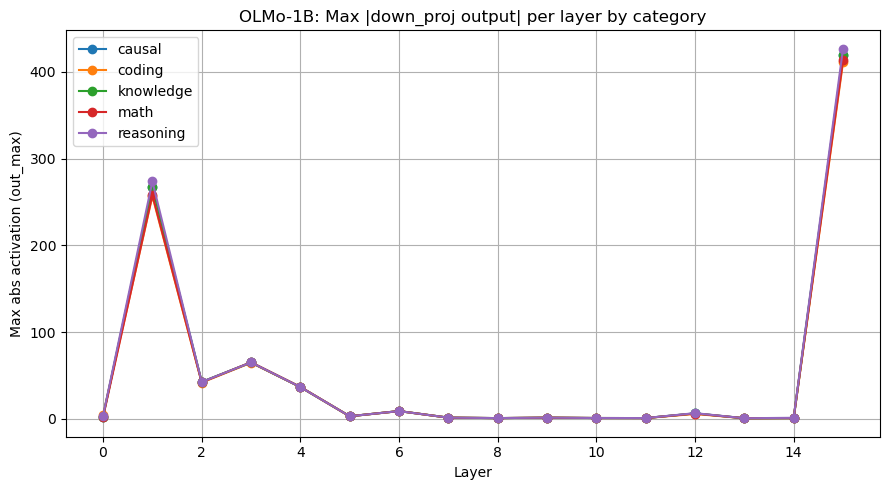

In [13]:
plot_activation(
    results,
    title="OLMo-1B: Max |down_proj output| per layer by category",
    key="out_max"
)

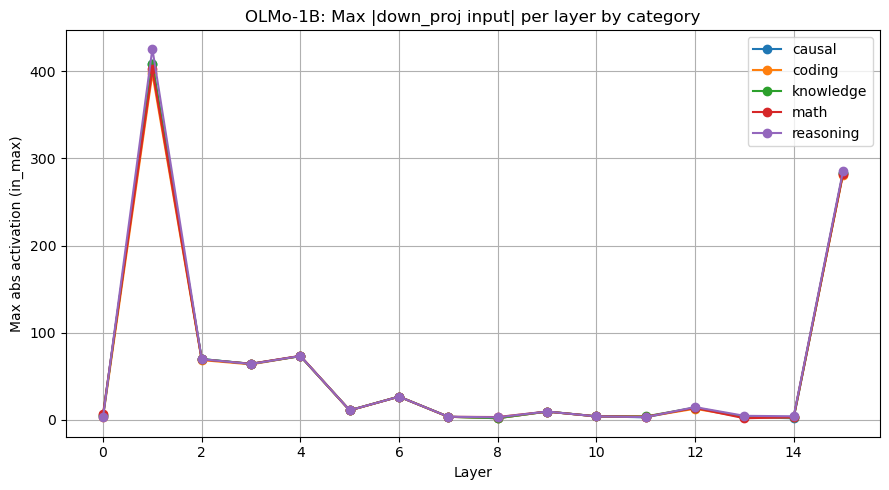

In [8]:
plot_activation(
    results,
    title="OLMo-1B: Max |down_proj input| per layer by category",
    key="in_max"
)

In [14]:
top_k = 10
top_candidates = df.head(top_k)

display(top_candidates[["layer", "out_idx", "in_idx", "weight", "score"]])

,layer,out_idx,in_idx,weight,score
0,1,1764,1710,0.632324,4.175008e+06
1,1,1764,7579,-0.378662,2.500169e+06
2,15,1764,3454,-0.828125,2.066391e+06
3,15,1764,6840,-0.726074,1.811747e+06
4,1,1764,7845,-0.210205,1.387908e+06
5,1,623,1710,0.058563,3.866719e+05
6,15,623,3454,-0.100891,2.517500e+05
7,15,1764,4239,0.095703,2.388046e+05
8,3,1764,1902,0.574707,1.891695e+05
9,2,1764,8041,-0.592285,1.825747e+05


In [17]:
original_weights = ablate_candidates(model, top_candidates)

In [18]:
results_after = {}

for name, texts in categories.items():
    stats = collect_activation_stats(model, tokenizer, texts)
    results_after[name] = stats

In [19]:
def plot_before_after(before, after, key="out_max", title=""):
    plt.figure(figsize=(10,5))

    for category in before.keys():
        before_vals = [l[key] for l in before[category]]
        after_vals = [l[key] for l in after[category]]

        plt.plot(before_vals, linestyle="--", label=f"{category} (before)")
        plt.plot(after_vals, linestyle="-", label=f"{category} (after)")

    plt.xlabel("Layer")
    plt.ylabel(f"Max abs activation ({key})")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

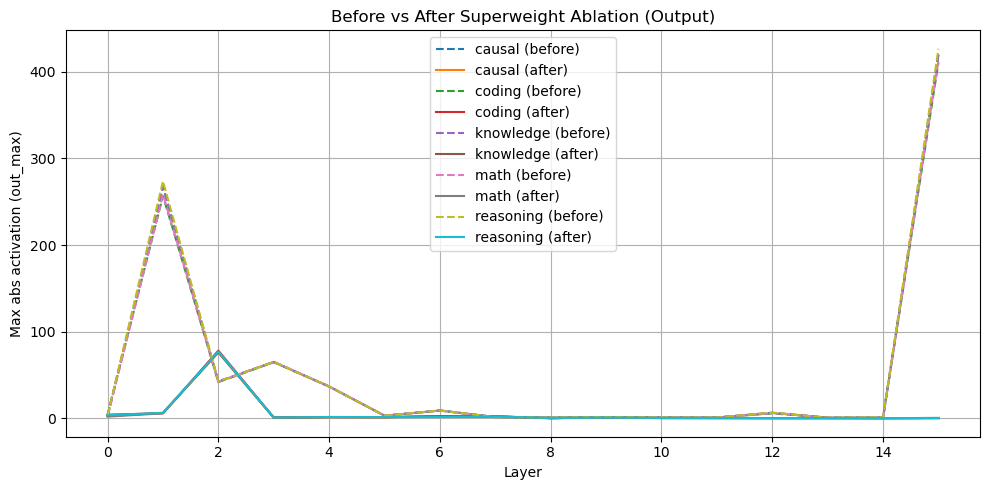

In [20]:
plot_before_after(
    results,
    results_after,
    key="out_max",
    title="Before vs After Superweight Ablation (Output)"
)

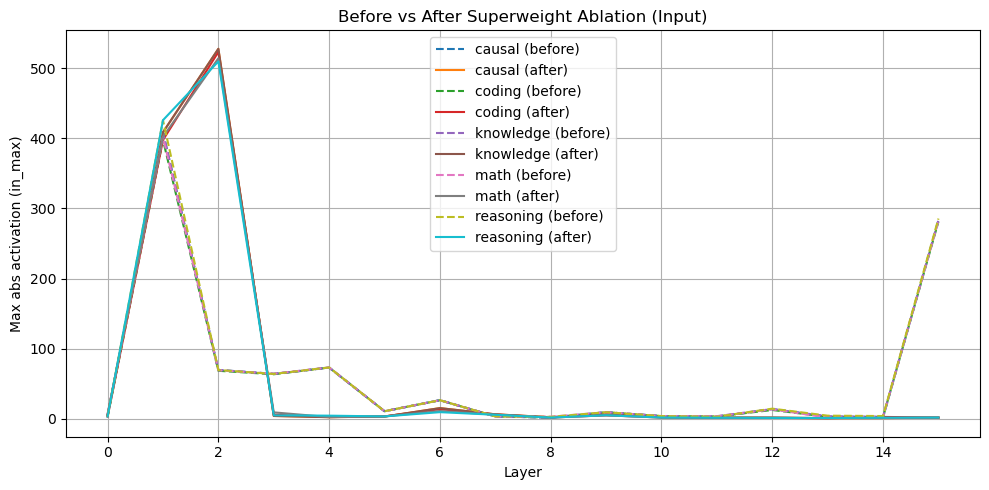

In [21]:
plot_before_after(
    results,
    results_after,
    key="in_max",
    title="Before vs After Superweight Ablation (Input)"
)

In [22]:
top_k = 50   # z.B. 25, 50, 100, 200
top_candidates = df.head(top_k)

display(top_candidates[["layer", "out_idx", "in_idx", "weight", "score"]].head(20))
print(f"Ablating top {top_k} candidates")

,layer,out_idx,in_idx,weight,score
0,1,1764,1710,0.632324,4.175008e+06
1,1,1764,7579,-0.378662,2.500169e+06
2,15,1764,3454,-0.828125,2.066391e+06
3,15,1764,6840,-0.726074,1.811747e+06
4,1,1764,7845,-0.210205,1.387908e+06
5,1,623,1710,0.058563,3.866719e+05
6,15,623,3454,-0.100891,2.517500e+05
7,15,1764,4239,0.095703,2.388046e+05
8,3,1764,1902,0.574707,1.891695e+05
9,2,1764,8041,-0.592285,1.825747e+05


Ablating top 50 candidates


In [23]:
original_weights = ablate_candidates(model, top_candidates)

In [24]:
results_after = {}

for name, texts in categories.items():
    stats = collect_activation_stats(model, tokenizer, texts)
    results_after[name] = stats

In [25]:
@torch.no_grad()
def restore_candidates(model, originals):
    layers = get_transformer_layers(model)

    for layer, out_idx, in_idx, value in originals:
        W = get_down_proj(layers[layer]).weight
        W[out_idx, in_idx] = value

In [26]:
# 1. restore old ablation if needed
restore_candidates(model, original_weights)

# 2. choose new top-k
top_k = 50
top_candidates = df.head(top_k)

# 3. ablate
original_weights = ablate_candidates(model, top_candidates)

# 4. recompute activations
results_after = {}
for name, texts in categories.items():
    results_after[name] = collect_activation_stats(model, tokenizer, texts)

In [33]:
k_values = [1,2,5,10, 25, 50, 100, 200]
all_results = {}

for k in k_values:
    # Modell zurücksetzen
    if "original_weights" in locals() and original_weights is not None:
        restore_candidates(model, original_weights)

    # neue Kandidaten
    top_candidates = df.head(k)

    # ablation
    original_weights = ablate_candidates(model, top_candidates)

    # activations neu berechnen
    results_after = {}
    for name, texts in categories.items():
        results_after[name] = collect_activation_stats(model, tokenizer, texts)

    all_results[k] = results_after

print("Done.")

Done.


In [34]:
def plot_multiple_ablation_levels(results_before, all_results, category="reasoning", key="in_max"):
    plt.figure(figsize=(10, 5))

    before_vals = [x[key] for x in results_before[category]]
    plt.plot(before_vals, marker="o", linestyle="--", label="before")

    for k, res in all_results.items():
        vals = [x[key] for x in res[category]]
        plt.plot(vals, marker="o", label=f"top-{k}")

    plt.xlabel("Layer")
    plt.ylabel(f"Max abs activation ({key})")
    plt.title(f"{category}: activation after ablating more candidates")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

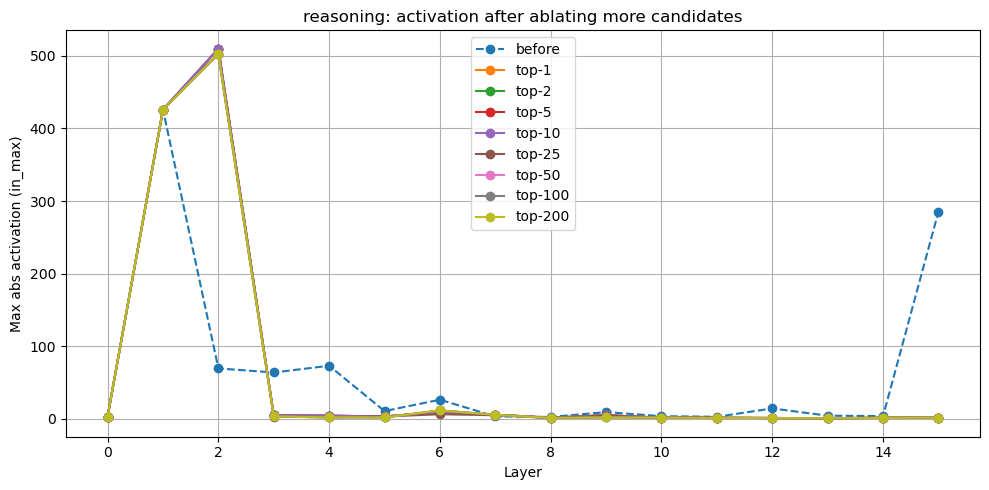

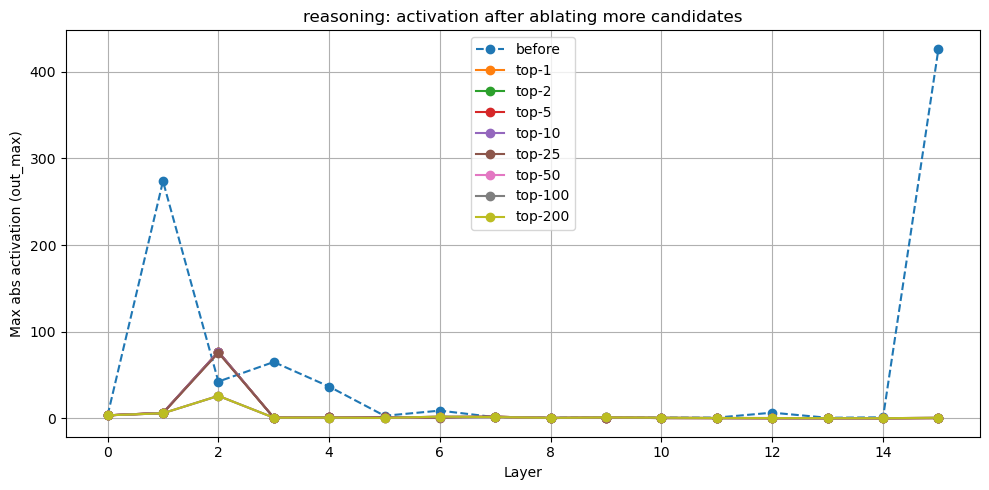

In [35]:
plot_multiple_ablation_levels(results, all_results, category="reasoning", key="in_max")
plot_multiple_ablation_levels(results, all_results, category="reasoning", key="out_max")

## TinyLlama

In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# =========================================================
# Helpers
# =========================================================

def get_transformer_layers(model):
    # Phi-3 / LLaMA / Mistral
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers

    # OLMo-style fallback
    if hasattr(model, "model") and hasattr(model.model, "transformer") and hasattr(model.model.transformer, "blocks"):
        return model.model.transformer.blocks

    # GPT-style fallback
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h

    raise ValueError("Unknown transformer layer structure")

def get_down_proj(layer):
    # Phi-3 / LLaMA / Mistral
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "down_proj"):
        return layer.mlp.down_proj

    # fallback
    if hasattr(layer, "feed_forward") and hasattr(layer.feed_forward, "w2"):
        return layer.feed_forward.w2

    raise ValueError("down_proj not found")

# =========================================================
# Activation collection
# =========================================================

@torch.no_grad()
def collect_activation_stats(model, tokenizer, texts):
    model.eval()
    device = next(model.parameters()).device
    layers = get_transformer_layers(model)

    layer_stats = [{"in_max": 0.0, "out_max": 0.0} for _ in range(len(layers))]
    hooks = []

    for i, layer in enumerate(layers):
        down_proj = get_down_proj(layer)

        def make_hook(layer_idx):
            def hook(module, inputs, outputs):
                x = inputs[0].detach()
                y = outputs.detach()

                in_val = x.abs().max().item()
                out_val = y.abs().max().item()

                layer_stats[layer_idx]["in_max"] = max(layer_stats[layer_idx]["in_max"], in_val)
                layer_stats[layer_idx]["out_max"] = max(layer_stats[layer_idx]["out_max"], out_val)
            return hook

        hooks.append(down_proj.register_forward_hook(make_hook(i)))

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
        _ = model(**inputs)

    for h in hooks:
        h.remove()

    return layer_stats

# =========================================================
# Candidate extraction
# =========================================================

@torch.no_grad()
def find_superweight_candidates(
    model,
    tokenizer,
    prompt,
    top_layers=8,
    top_input_channels=8,
    top_output_channels=8,
):
    model.eval()
    device = next(model.parameters()).device
    layers = get_transformer_layers(model)

    stats = []
    hooks = []

    for layer_idx, layer in enumerate(layers):
        down_proj = get_down_proj(layer)

        store = {
            "layer": layer_idx,
            "in_vals": None,
            "out_vals": None,
        }

        def make_hook(store_ref):
            def hook(module, inputs, outputs):
                x = inputs[0].detach()
                y = outputs.detach()

                x_abs = x.abs().reshape(-1, x.shape[-1])
                y_abs = y.abs().reshape(-1, y.shape[-1])

                store_ref["in_vals"] = x_abs.max(dim=0).values.cpu()
                store_ref["out_vals"] = y_abs.max(dim=0).values.cpu()
            return hook

        hooks.append(down_proj.register_forward_hook(make_hook(store)))
        stats.append(store)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128).to(device)
    _ = model(**inputs)

    for h in hooks:
        h.remove()

    layer_scores = []
    for s in stats:
        if s["in_vals"] is None or s["out_vals"] is None:
            continue

        in_peak = s["in_vals"].max().item()
        out_peak = s["out_vals"].max().item()
        in_med = s["in_vals"].median().item() + 1e-12
        out_med = s["out_vals"].median().item() + 1e-12

        score = (in_peak / in_med) * (out_peak / out_med)

        layer_scores.append({
            "layer": s["layer"],
            "score": score,
            "in_vals": s["in_vals"],
            "out_vals": s["out_vals"],
        })

    layer_scores = sorted(layer_scores, key=lambda x: x["score"], reverse=True)

    candidates = []
    for row in layer_scores[:top_layers]:
        layer_idx = row["layer"]
        in_vals = row["in_vals"]
        out_vals = row["out_vals"]

        top_in = torch.topk(in_vals, k=min(top_input_channels, in_vals.numel()))
        top_out = torch.topk(out_vals, k=min(top_output_channels, out_vals.numel()))

        W = get_down_proj(layers[layer_idx]).weight.detach().cpu()

        for out_idx in top_out.indices.tolist():
            for in_idx in top_in.indices.tolist():
                weight_val = W[out_idx, in_idx].item()
                candidates.append({
                    "layer": layer_idx,
                    "out_idx": out_idx,
                    "in_idx": in_idx,
                    "weight": weight_val,
                    "abs_weight": abs(weight_val),
                    "score": row["score"] * abs(weight_val),
                })

    df = pd.DataFrame(candidates)
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    return df

# =========================================================
# Ablation / restore
# =========================================================

@torch.no_grad()
def ablate_candidates(model, candidates):
    layers = get_transformer_layers(model)
    originals = []

    for _, row in candidates.iterrows():
        layer = int(row["layer"])
        out_idx = int(row["out_idx"])
        in_idx = int(row["in_idx"])

        W = get_down_proj(layers[layer]).weight
        original_value = W[out_idx, in_idx].item()
        originals.append((layer, out_idx, in_idx, original_value))

        W[out_idx, in_idx] = 0.0

    return originals

@torch.no_grad()
def restore_candidates(model, originals):
    layers = get_transformer_layers(model)

    for layer, out_idx, in_idx, value in originals:
        W = get_down_proj(layers[layer]).weight
        W[out_idx, in_idx] = value

# =========================================================
# Plotting
# =========================================================

def plot_before_after(before, after, key="out_max", title=""):
    plt.figure(figsize=(10, 5))

    for category in before.keys():
        before_vals = [x[key] for x in before[category]]
        after_vals = [x[key] for x in after[category]]

        plt.plot(before_vals, linestyle="--", marker="o", label=f"{category} (before)")
        plt.plot(after_vals, linestyle="-", marker="o", label=f"{category} (after)")

    plt.xlabel("Layer")
    plt.ylabel(f"Max abs activation ({key})")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
categories = {
    "causal": ["The sky is blue because"],
    "coding": ["Write a Python function to sort a list."],
    "knowledge": ["The capital of Germany is"],
    "math": ["27 * 14 ="],
    "reasoning": ["If all cats are animals and some animals bark, what follows?"],
}

In [5]:
def run_superweight_experiment(model_id, prompt, top_k=50):
    print(f"\n=== Running: {model_id} ===")

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    model.eval()

    # BEFORE
    results_before = {}
    for name, texts in categories.items():
        results_before[name] = collect_activation_stats(model, tokenizer, texts)

    # CANDIDATES
    df = find_superweight_candidates(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        top_layers=8,
        top_input_channels=8,
        top_output_channels=8,
    )

    print("\nTop candidates:")
    display(df.head(10))

    # ABLATE
    top_candidates = df.head(top_k)
    originals = ablate_candidates(model, top_candidates)

    # AFTER
    results_after = {}
    for name, texts in categories.items():
        results_after[name] = collect_activation_stats(model, tokenizer, texts)

    # PLOTS
    plot_before_after(
        results_before,
        results_after,
        key="in_max",
        title=f"{model_id}: Before vs After Superweight Ablation (Input, top-{top_k})"
    )

    plot_before_after(
        results_before,
        results_after,
        key="out_max",
        title=f"{model_id}: Before vs After Superweight Ablation (Output, top-{top_k})"
    )

    return model, tokenizer, df, results_before, results_after, originals

In [19]:
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
torch.cuda.empty_cache()

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [20]:
tiny_before = {}
for name, texts in categories.items():
    tiny_before[name] = collect_activation_stats(model, tokenizer, texts)

In [21]:
tiny_df = find_superweight_candidates(
    model=model,
    tokenizer=tokenizer,
    prompt="The capital of France is",
    top_layers=8,
    top_input_channels=8,
    top_output_channels=8,
)

In [22]:
tiny_unique = tiny_df.drop_duplicates(subset=["layer", "out_idx", "in_idx"]).reset_index(drop=True)
display(tiny_unique.head(20))
print("Unique candidates:", len(tiny_unique))

,layer,out_idx,in_idx,weight,abs_weight,score
0,2,624,5475,-0.835938,0.835938,2.419215e+07
1,2,1661,5475,-0.613281,0.613281,1.774844e+07
2,2,624,3610,0.490234,0.490234,1.418745e+07
3,2,1661,3610,0.187500,0.187500,5.426276e+06
4,2,624,385,-0.154297,0.154297,4.465373e+06
5,2,624,3950,-0.148438,0.148438,4.295802e+06
6,2,758,5475,0.129883,0.129883,3.758826e+06
7,2,624,3478,-0.124512,0.124512,3.603386e+06
8,2,758,4942,-0.095703,0.095703,2.769662e+06
9,2,758,2075,0.078613,0.078613,2.275079e+06


Unique candidates: 512


In [23]:
top_k = 25
tiny_top = tiny_unique.head(top_k)
tiny_originals = ablate_candidates(model, tiny_top)

In [24]:
tiny_after = {}
for name, texts in categories.items():
    tiny_after[name] = collect_activation_stats(model, tokenizer, texts)

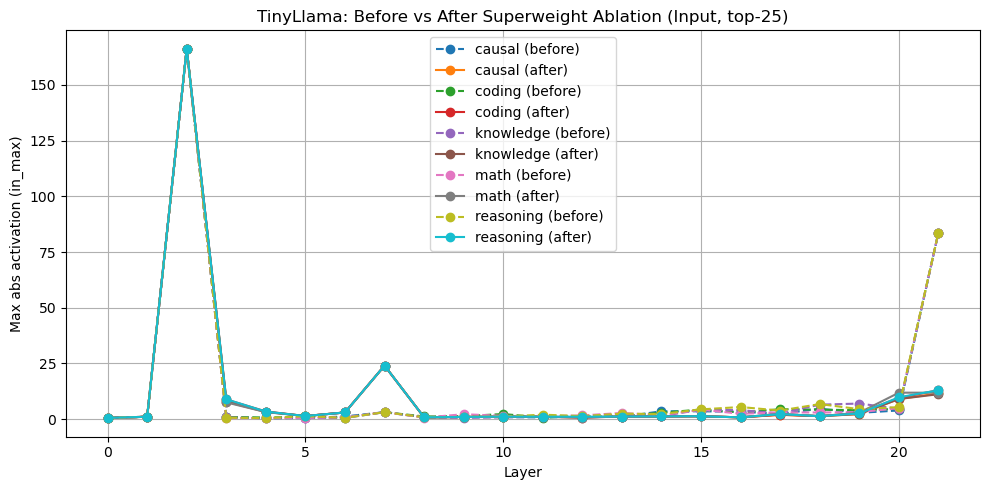

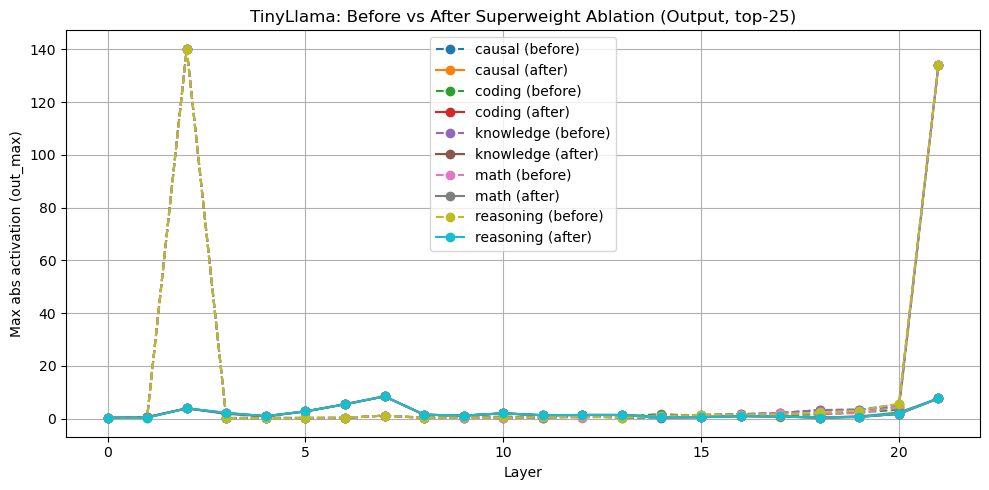

In [25]:
plot_before_after(
    tiny_before,
    tiny_after,
    key="in_max",
    title=f"TinyLlama: Before vs After Superweight Ablation (Input, top-{top_k})"
)

plot_before_after(
    tiny_before,
    tiny_after,
    key="out_max",
    title=f"TinyLlama: Before vs After Superweight Ablation (Output, top-{top_k})"
)

## Phi-3

In [1]:
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
torch.cuda.empty_cache()

model_id = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")

model.eval()
print("Phi-3 loaded.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi-3 loaded.


In [2]:
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
_ = model(**inputs)
print("Forward pass works.")

Forward pass works.


In [3]:
categories_phi = {
    "causal": ["The sky is blue because"],
    "coding": ["Write a Python function to sort a list."],
    "knowledge": ["The capital of Germany is"],
    "math": ["27 * 14 ="],
    "reasoning": ["If all cats are animals and some animals bark, what follows?"],
}

In [4]:
import torch

@torch.no_grad()
def collect_activation_stats(model, tokenizer, texts):
    layers = get_transformer_layers(model)

    stats = []

    hooks = []
    layer_outputs = {}

    def make_hook(i):
        def hook(module, inputs, outputs):
            x = inputs[0].detach()
            y = outputs.detach()

            layer_outputs[i] = {
                "in_max": x.abs().max().item(),
                "out_max": y.abs().max().item(),
            }
        return hook

    # register hooks
    for i, layer in enumerate(layers):
        down_proj = get_down_proj(layer)
        hooks.append(down_proj.register_forward_hook(make_hook(i)))

    # run texts
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        _ = model(**inputs)

    # collect
    for i in range(len(layers)):
        stats.append(layer_outputs.get(i, {"in_max": 0, "out_max": 0}))

    # remove hooks
    for h in hooks:
        h.remove()

    return stats

In [6]:
import torch

# =========================
# 1. Transformer Layers finden
# =========================
def get_transformer_layers(model):
    # Phi-3
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers

    # LLaMA / Mistral / TinyLlama
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers

    # fallback (manchmal anders verschachtelt)
    if hasattr(model, "layers"):
        return model.layers

    raise ValueError("Could not find transformer layers. Try print(model) to inspect.")


# =========================
# 2. MLP Down Projection finden (SUPER IMPORTANT)
# =========================
def get_down_proj(layer):
    # LLaMA / Mistral / TinyLlama
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "down_proj"):
        return layer.mlp.down_proj

    # Phi-3 (gleiches Pattern meistens)
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "down_proj"):
        return layer.mlp.down_proj

    raise ValueError("down_proj not found in this layer")


# =========================
# 3. Activation Stats sammeln
# =========================
@torch.no_grad()
def collect_activation_stats(model, tokenizer, texts):
    layers = get_transformer_layers(model)

    stats = []
    hooks = []
    layer_outputs = {}

    def make_hook(i):
        def hook(module, inputs, outputs):
            x = inputs[0].detach()
            y = outputs.detach()

            layer_outputs[i] = {
                "in_max": x.abs().max().item(),
                "out_max": y.abs().max().item(),
            }
        return hook

    # hooks registrieren
    for i, layer in enumerate(layers):
        down_proj = get_down_proj(layer)
        hooks.append(down_proj.register_forward_hook(make_hook(i)))

    # forward pass
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        _ = model(**inputs)

    # sammeln
    for i in range(len(layers)):
        stats.append(layer_outputs.get(i, {"in_max": 0, "out_max": 0}))

    # hooks entfernen
    for h in hooks:
        h.remove()

    return stats


# =========================
# 4. Ablation Funktion
# =========================
@torch.no_grad()
def ablate_candidates(model, candidates):
    layers = get_transformer_layers(model)

    originals = []

    for _, row in candidates.iterrows():
        l = int(row["layer"])
        o = int(row["out_idx"])
        i = int(row["in_idx"])

        W = get_down_proj(layers[l]).weight

        original_value = W[o, i].item()
        originals.append((l, o, i, original_value))

        W[o, i] = 0.0

    return originals

In [ ]:
phi_before = {}
for name, texts in categories_phi.items():
    phi_before[name] = collect_activation_stats(model, tokenizer, texts)

In [1]:
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
torch.cuda.empty_cache()

model_id = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")

model.eval()
print("Phi-3 loaded")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi-3 loaded


In [2]:
inputs = tokenizer("The capital of France is", return_tensors="pt").to("cuda")
_ = model(**inputs)
print("Forward works")

Forward works


In [3]:
texts = ["The capital of France is"]

In [8]:
@torch.no_grad()
def collect_activation_stats(model, tokenizer, texts):
    layers = get_transformer_layers(model)
    stats = [{"in_max": 0.0, "out_max": 0.0} for _ in range(len(layers))]
    hooks = []

    def make_hook(i):
        def hook(module, inputs, outputs):
            x = inputs[0]
            y = outputs

            stats[i]["in_max"] = max(stats[i]["in_max"], float(x.detach().abs().max().item()))
            stats[i]["out_max"] = max(stats[i]["out_max"], float(y.detach().abs().max().item()))
        return hook

    for i, layer in enumerate(layers):
        hooks.append(get_down_proj(layer).register_forward_hook(make_hook(i)))

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to("cuda")
        _ = model(**inputs)

    for h in hooks:
        h.remove()

    return stats

In [9]:
import torch
import pandas as pd

@torch.no_grad()
def find_superweight_candidates(
    model,
    tokenizer,
    prompt,
    top_layers=4,
    top_input_channels=4,
    top_output_channels=4,
):
    layers = get_transformer_layers(model)

    # 1. Aktivierungen sammeln (für einen Prompt!)
    activations = []

    hooks = []
    layer_data = {}

    def make_hook(i):
        def hook(module, inputs, outputs):
            x = inputs[0].detach()   # [B, S, H_in]
            y = outputs.detach()     # [B, S, H_out]

            x_abs = x.abs().reshape(-1, x.shape[-1])
            y_abs = y.abs().reshape(-1, y.shape[-1])

            layer_data[i] = {
                "in_max": x_abs.max(dim=0).values,   # [H_in]
                "out_max": y_abs.max(dim=0).values,  # [H_out]
            }
        return hook

    # hooks registrieren
    for i, layer in enumerate(layers):
        hooks.append(get_down_proj(layer).register_forward_hook(make_hook(i)))

    # forward pass (nur 1 prompt!)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=64).to(model.device)
    _ = model(**inputs)

    # hooks entfernen
    for h in hooks:
        h.remove()

    # 2. Scores berechnen
    candidates = []

    for i, layer in enumerate(layers):
        if i not in layer_data:
            continue

        in_max = layer_data[i]["in_max"]
        out_max = layer_data[i]["out_max"]

        W = get_down_proj(layer).weight  # [H_out, H_in]

        # Top Input Channels
        top_in = torch.topk(in_max, k=min(top_input_channels, len(in_max))).indices

        # Top Output Channels
        top_out = torch.topk(out_max, k=min(top_output_channels, len(out_max))).indices

        # Kombinieren → Kandidaten
        for o in top_out:
            for inp in top_in:
                weight = W[o, inp].item()
                score = abs(weight) * in_max[inp].item() * out_max[o].item()

                candidates.append({
                    "layer": i,
                    "out_idx": int(o),
                    "in_idx": int(inp),
                    "weight": weight,
                    "abs_weight": abs(weight),
                    "score": score,
                })

    df = pd.DataFrame(candidates)

    # global sortieren
    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    return df

In [13]:
phi_df = find_superweight_candidates(
    model=model,
    tokenizer=tokenizer,
    prompt="The capital of France is",
    top_layers=3,
    top_input_channels=3,
    top_output_channels=3,
)

In [14]:
phi_unique = phi_df.drop_duplicates(subset=["layer", "out_idx", "in_idx"]).reset_index(drop=True)
display(phi_unique.head(10))

,layer,out_idx,in_idx,weight,abs_weight,score
0,2,1693,340,3.125000,3.125000,2.880574e+08
1,2,525,808,-2.921875,2.921875,2.693337e+08
2,4,525,2723,-2.578125,2.578125,1.852494e+08
3,2,1113,340,-1.976562,1.976562,1.821963e+08
4,2,1113,808,-1.734375,1.734375,1.598719e+08
5,2,1693,808,1.718750,1.718750,1.584316e+08
6,2,525,340,-1.328125,1.328125,1.224244e+08
7,4,1113,2723,-1.671875,1.671875,1.201315e+08
8,4,1693,2723,1.609375,1.609375,1.156406e+08
9,4,1113,7487,1.117188,1.117188,8.027476e+07


In [15]:
top_k = 25
phi_top = phi_unique.head(top_k)

phi_originals = ablate_candidates(model, phi_top)

In [16]:
phi_before = collect_activation_stats(model, tokenizer, ["The capital of France is"])
phi_after = collect_activation_stats(model, tokenizer, ["The capital of France is"])

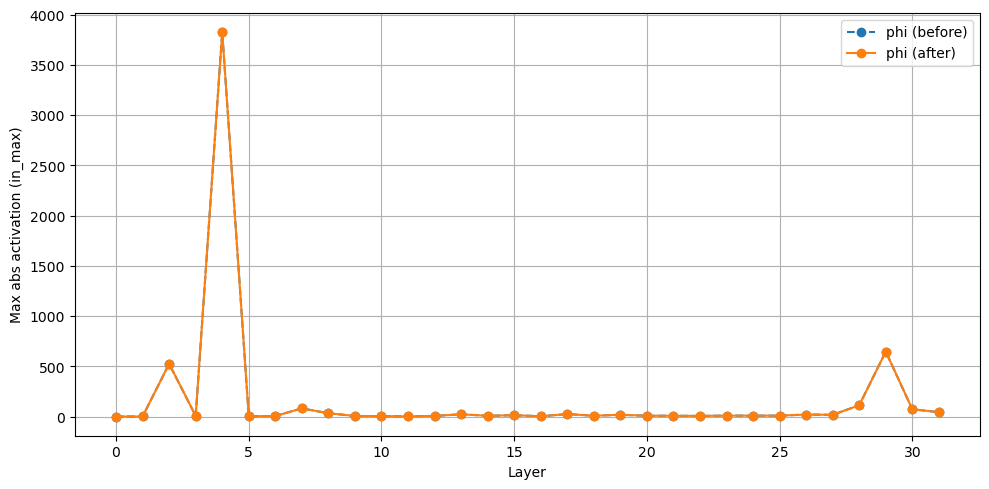

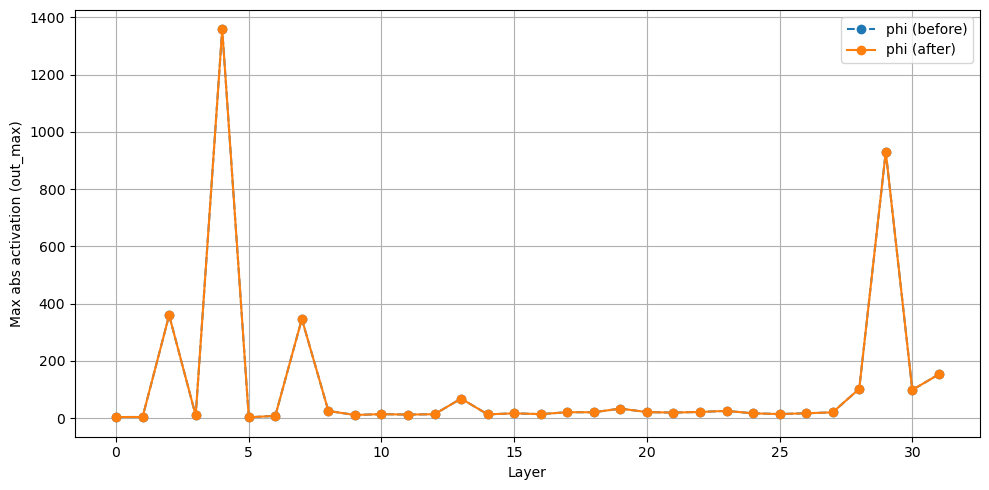

In [18]:
phi_before_dict = {"phi": phi_before}
phi_after_dict = {"phi": phi_after}

plot_before_after(phi_before_dict, phi_after_dict, key="in_max")
plot_before_after(phi_before_dict, phi_after_dict, key="out_max")

In [1]:
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
torch.cuda.empty_cache()

model_id = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")

model.eval()
print("Phi-3 loaded.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi-3 loaded.


In [4]:
phi_before = collect_activation_stats(model, tokenizer, ["The capital of France is"])

In [5]:
phi_df = find_superweight_candidates(
    model=model,
    tokenizer=tokenizer,
    prompt="The capital of France is",
    top_layers=3,
    top_input_channels=3,
    top_output_channels=3,
)

phi_unique = phi_df.drop_duplicates(subset=["layer", "out_idx", "in_idx"]).reset_index(drop=True)
display(phi_unique.head(10))

,layer,out_idx,in_idx,weight,abs_weight,score
0,2,1693,340,3.125000,3.125000,2.880574e+08
1,2,525,808,-2.921875,2.921875,2.693337e+08
2,4,525,2723,-2.578125,2.578125,1.852494e+08
3,2,1113,340,-1.976562,1.976562,1.821963e+08
4,2,1113,808,-1.734375,1.734375,1.598719e+08
5,2,1693,808,1.718750,1.718750,1.584316e+08
6,2,525,340,-1.328125,1.328125,1.224244e+08
7,4,1113,2723,-1.671875,1.671875,1.201315e+08
8,4,1693,2723,1.609375,1.609375,1.156406e+08
9,4,1113,7487,1.117188,1.117188,8.027476e+07


In [6]:
phi_top = phi_unique.head(10)
phi_originals = ablate_candidates(model, phi_top)

In [7]:
layers = get_transformer_layers(model)

for _, row in phi_top.head(5).iterrows():
    l = int(row["layer"])
    o = int(row["out_idx"])
    i = int(row["in_idx"])
    W = get_down_proj(layers[l]).weight
    print(l, o, i, float(W[o, i].item()))

2 1693 340 0.0
2 525 808 0.0
4 525 2723 0.0
2 1113 340 0.0
2 1113 808 0.0


In [8]:
phi_after = collect_activation_stats(model, tokenizer, ["The capital of France is"])

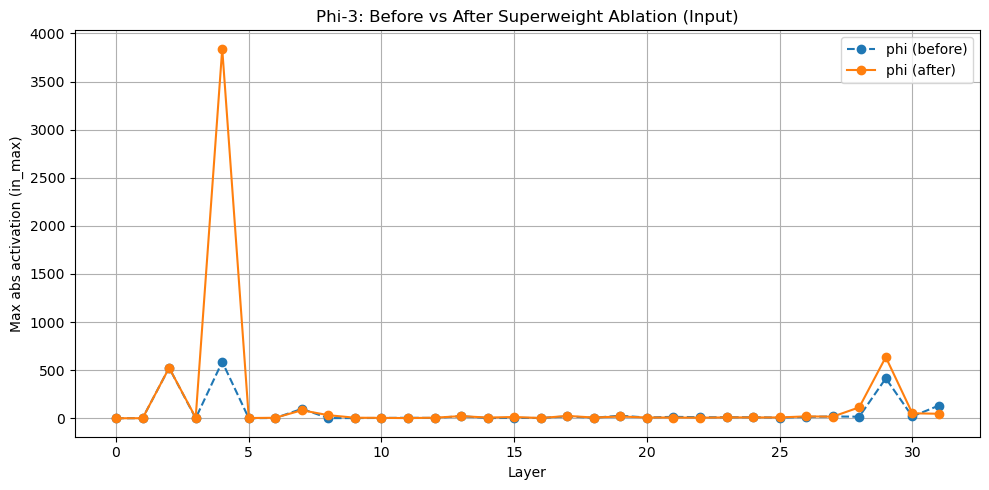

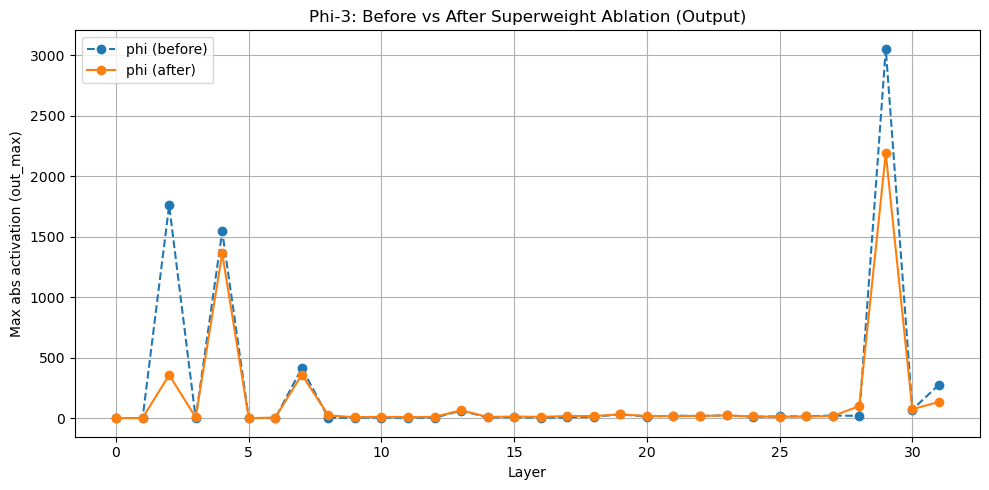

In [10]:
phi_before_dict = {"phi": phi_before}
phi_after_dict = {"phi": phi_after}

plot_before_after(
    phi_before_dict,
    phi_after_dict,
    key="in_max",
    title="Phi-3: Before vs After Superweight Ablation (Input)"
)

plot_before_after(
    phi_before_dict,
    phi_after_dict,
    key="out_max",
    title="Phi-3: Before vs After Superweight Ablation (Output)"
)

In [11]:
before_in = [x["in_max"] for x in phi_before]
after_in = [x["in_max"] for x in phi_after]

before_out = [x["out_max"] for x in phi_before]
after_out = [x["out_max"] for x in phi_after]

print("Input identical:", before_in == after_in)
print("Output identical:", before_out == after_out)

Input identical: False
Output identical: False
